Purpose: Look at results of the HybridExpress re-run on top 30% of expression values (samples) for each gene in each genotype-treatment combination (this hopefully removed some false negatives from genes' expression being "averaged out" over time).<br>
Author: Anna Pardo<br>
Date initiated: Mar. 13, 2026

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# load results dataframe
res = pd.read_csv("./hybexp_top30pct_partitiongenes_bygttreat.txt",sep="\t",header="infer")
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [3]:
# split genotype & treatment info
gtt = res["genotype_treat"].str.split("_",expand=True)
gtt.rename(columns={0:"genotype",1:"treat"},inplace=True)
res = pd.concat([res,gtt],axis=1)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,18,D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D,18,D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D,18,D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D,18,D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D,18,D


In [4]:
physcat = json.load(open("/home/leviathan22/Yucca_genomics/phys_figures/physiological_CAM_categories.json"))

In [5]:
res["phys"] = res["genotype"].map(physcat)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,18,D,C3
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D,18,D,C3
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D,18,D,C3
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D,18,D,C3
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D,18,D,C3


In [6]:
len(res["Gene"].unique())

26669

## Make summary barplot figures

In [7]:
classcounts = res.groupby(["phys","genotype","treat","Class"]).count().reset_index()[["phys","genotype","treat","Class","Gene"]]
classcounts.head()

,phys,genotype,treat,Class,Gene
0,C3,13,D,ADD,3943
1,C3,13,D,DOWN,2181
2,C3,13,D,ELD_P1,5100
3,C3,13,D,ELD_P2,5245
4,C3,13,D,UP,2008


In [8]:
def subcounts(cdf,colname,colval):
    subdf = cdf[cdf[colname]==colval]
    return subdf.sort_values(by=["treat","phys"],ascending=False)

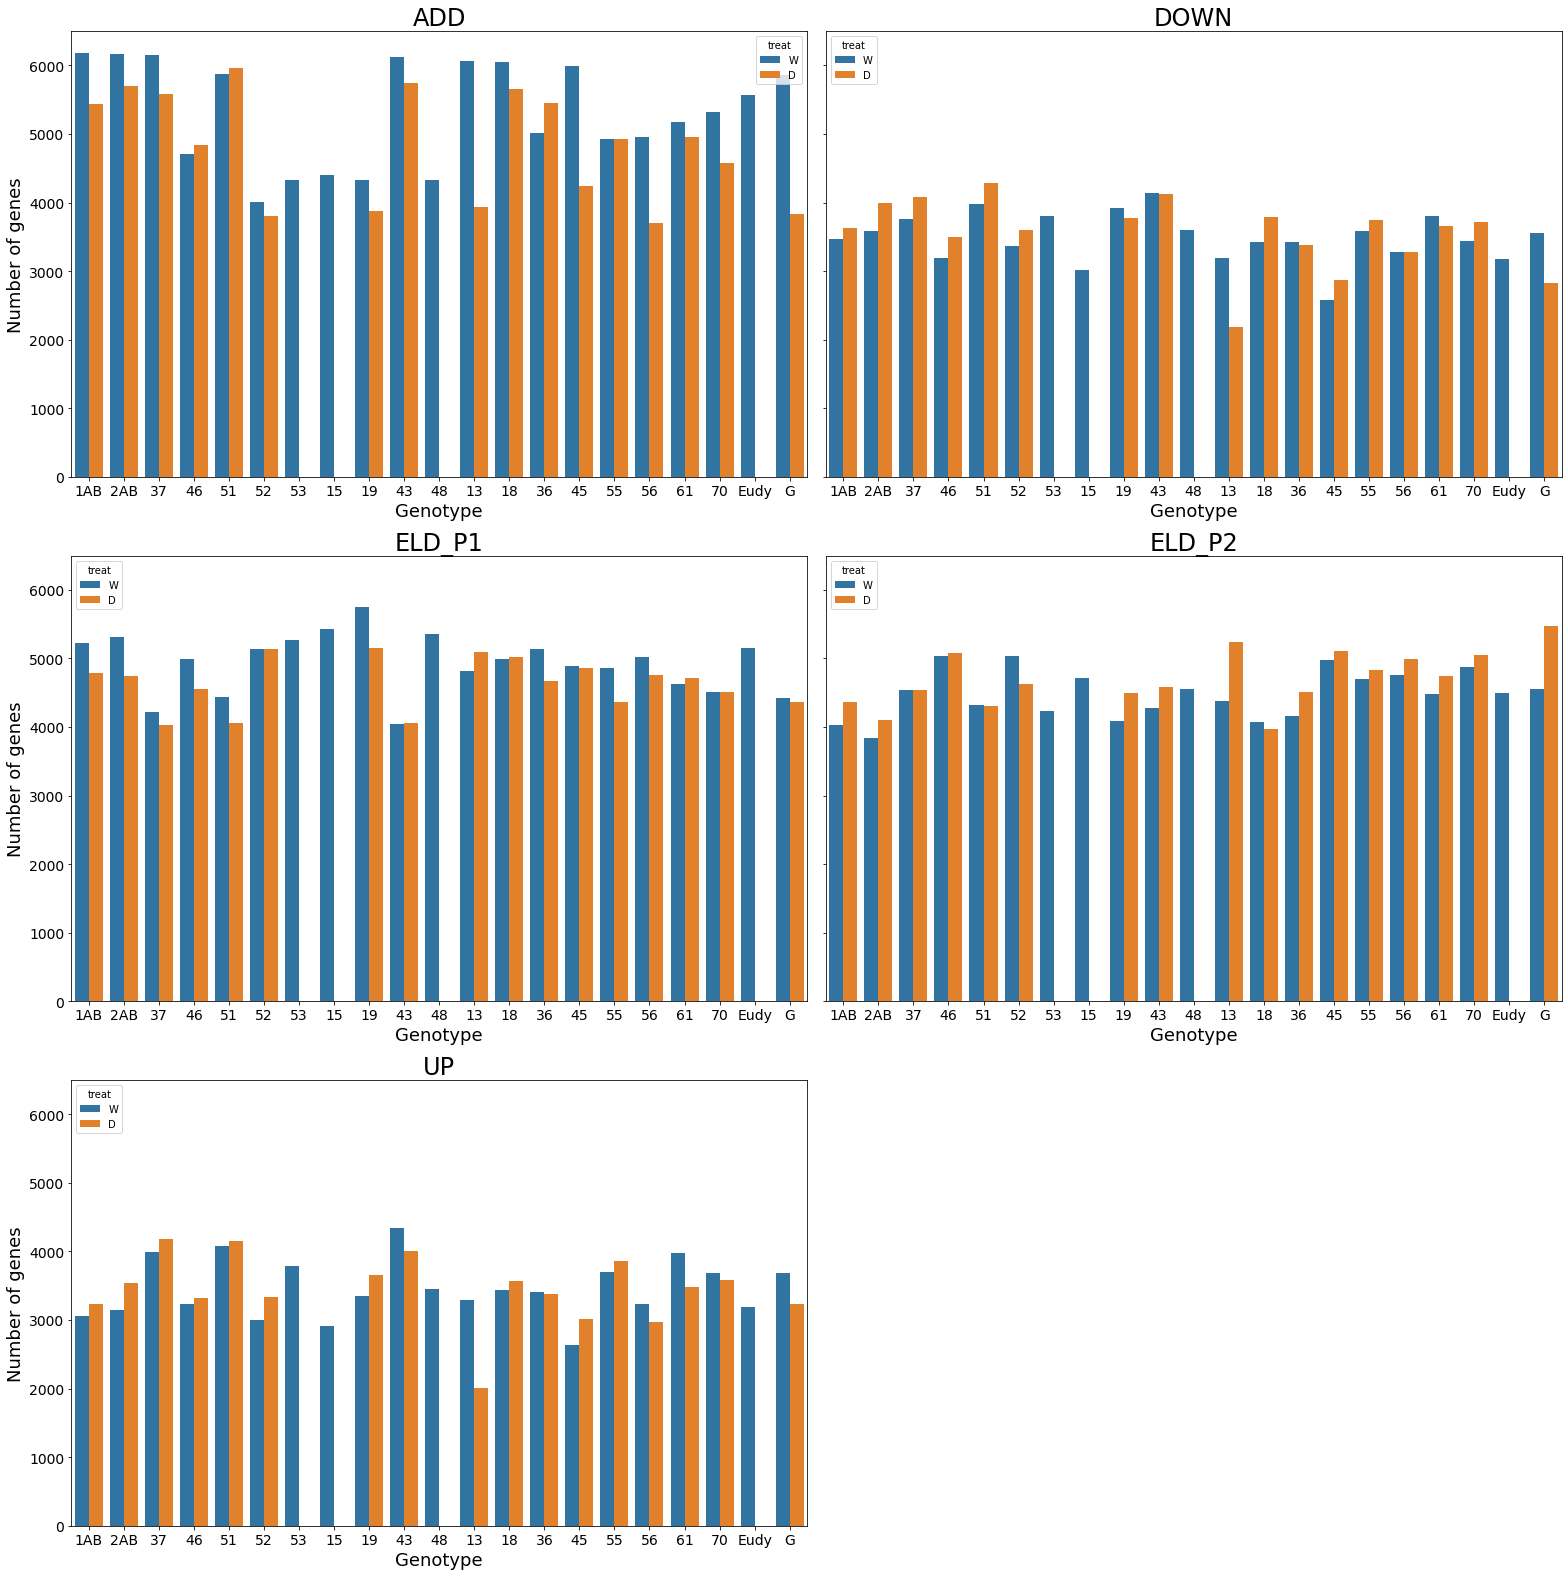

In [9]:
fig,ax = plt.subplots(nrows=3,ncols=2,figsize=(22,22),sharey=True)
r=0
c=0
for i in classcounts["Class"].unique():
    df = subcounts(classcounts,"Class",i)
    sns.barplot(ax=ax[r,c],data=df,x="genotype",y="Gene",hue="treat")
    ax[r,c].set_title(i,fontsize=24)
    ax[r,c].tick_params(which="both",labelsize=14)
    ax[r,c].set_xlabel("Genotype",fontsize=18)
    if c==0:
        ax[r,c].set_ylabel("Number of genes",fontsize=18)
    else:
        ax[r,c].set_ylabel("")
    
    if c<1:
        c+=1
    else:
        c=0
        r+=1
        
fig.tight_layout()
fig.delaxes(ax[2,1])

plt.savefig("./top30pct_figures/top30_ngenes_gttreat_class.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_ngenes_gttreat_class.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_ngenes_gttreat_class.svg",dpi=200,bbox_inches="tight")

In [10]:
classcounts["phys"].unique()

array(['C3', 'facultative_CAM', 'possible_fac_CAM'], dtype=object)

In [11]:
classcounts.sort_values(by=["treat","Class"],ascending=False,inplace=True)

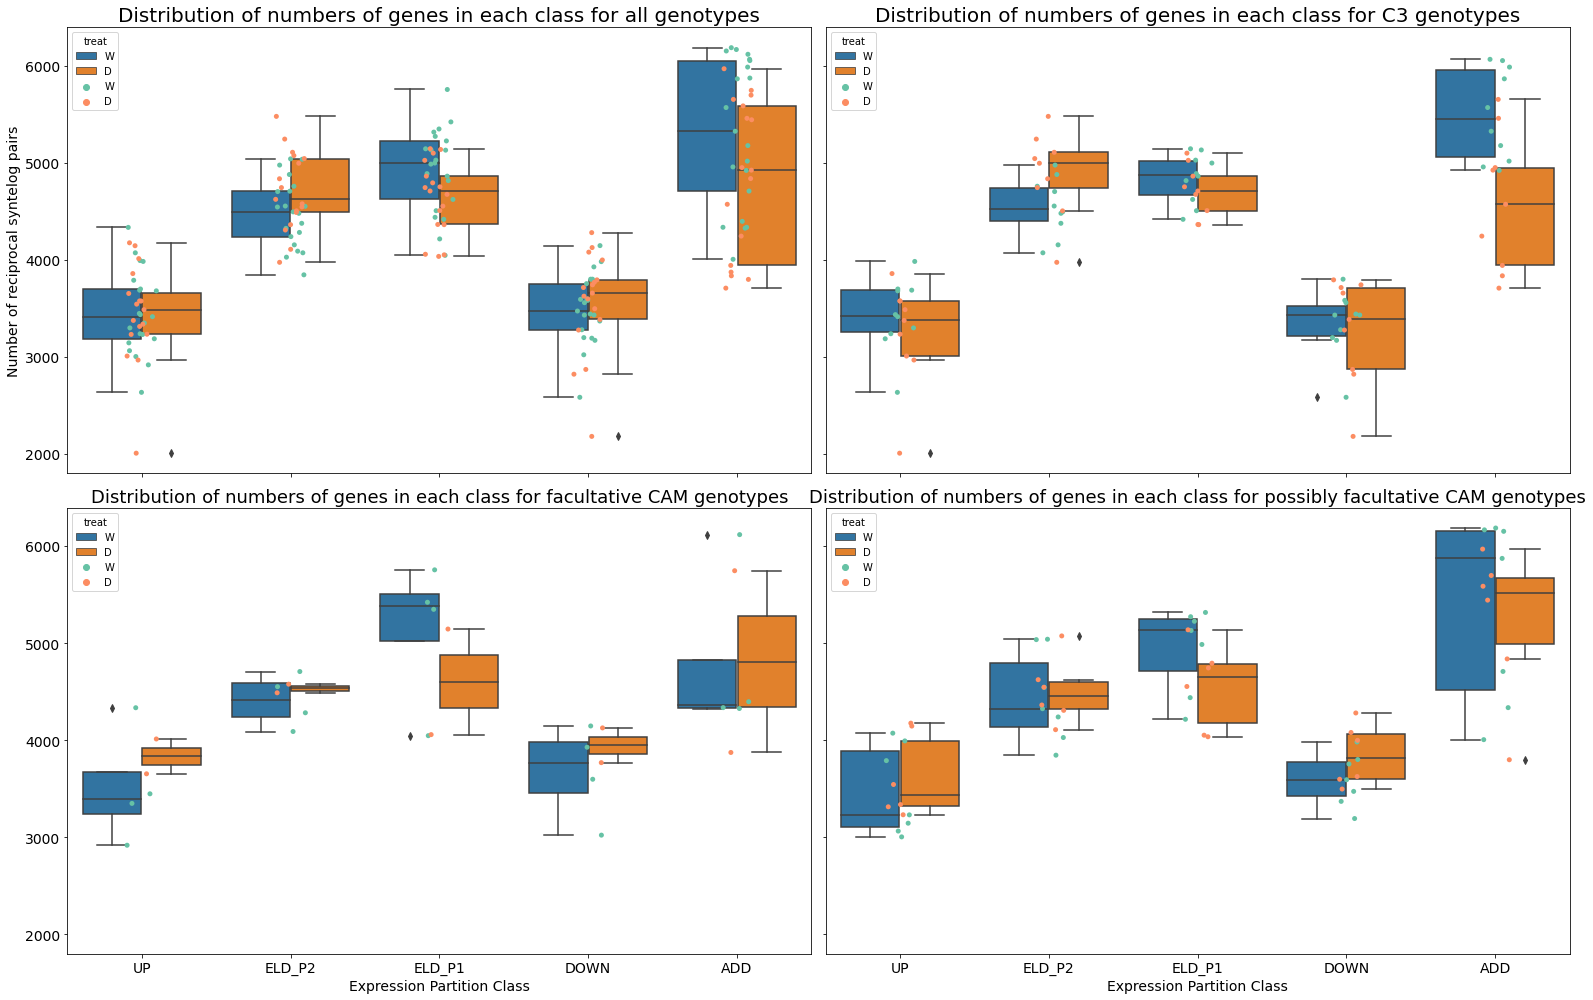

In [12]:
# make a boxplot: distribution of genotypes' numbers of genes per class (by treatment) with data points
# four of these: one with all genotypes, one with just genotypes from each physiological category
fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(22,14),sharex=True,sharey=True)

sns.boxplot(ax=ax[0,0],data=classcounts,x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[0,0],data=classcounts,x="Class",y="Gene",hue="treat",palette="Set2")
ax[0,0].set_title("Distribution of numbers of genes in each class for all genotypes",fontsize=20)
ax[0,0].tick_params(which="both",labelsize=14)
ax[0,0].set_ylabel("Number of reciprocal syntelog pairs",fontsize=14)
ax[0,0].set_xlabel("")

sns.boxplot(ax=ax[0,1],data=classcounts[classcounts["phys"]=="C3"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[0,1],data=classcounts[classcounts["phys"]=="C3"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[0,1].set_title("Distribution of numbers of genes in each class for C3 genotypes",fontsize=20)
ax[0,1].set_ylabel("")
ax[0,1].set_xlabel("")

sns.boxplot(ax=ax[1,1],data=classcounts[classcounts["phys"]=="possible_fac_CAM"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[1,1],data=classcounts[classcounts["phys"]=="possible_fac_CAM"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[1,1].set_title("Distribution of numbers of genes in each class for possibly facultative CAM genotypes",fontsize=18)
ax[1,1].set_ylabel("")
ax[1,1].set_xlabel("Expression Partition Class",fontsize=14)
ax[1,1].tick_params(which="both",labelsize=14)

sns.boxplot(ax=ax[1,0],data=classcounts[classcounts["phys"]=="facultative_CAM"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[1,0],data=classcounts[classcounts["phys"]=="facultative_CAM"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[1,0].set_title("Distribution of numbers of genes in each class for facultative CAM genotypes",fontsize=18)
ax[1,0].set_ylabel("")
ax[1,0].set_xlabel("Expression Partition Class",fontsize=14)
ax[1,0].tick_params(which="both",labelsize=14)

fig.tight_layout()

plt.savefig("./top30pct_figures/top30_boxplots_ngenes_byclass.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_boxplots_ngenes_byclass.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_boxplots_ngenes_byclass.svg",dpi=200,bbox_inches="tight")

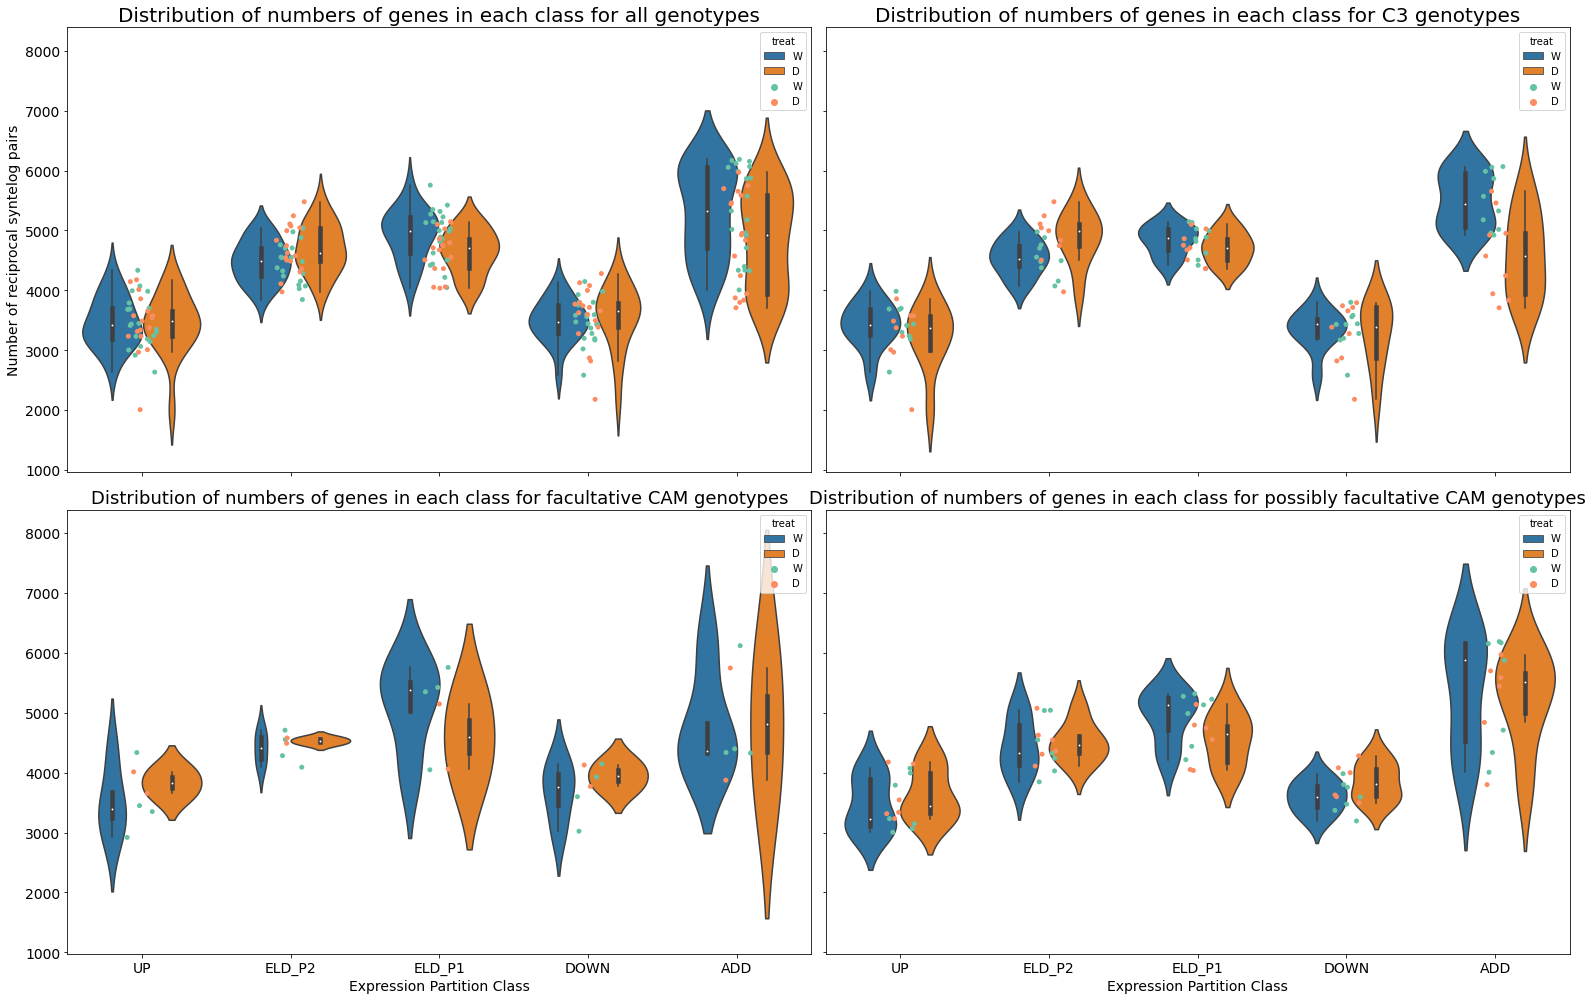

In [13]:
fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(22,14),sharex=True,sharey=True)

sns.violinplot(ax=ax[0,0],data=classcounts,x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[0,0],data=classcounts,x="Class",y="Gene",hue="treat",palette="Set2")
ax[0,0].set_title("Distribution of numbers of genes in each class for all genotypes",fontsize=20)
ax[0,0].tick_params(which="both",labelsize=14)
ax[0,0].set_ylabel("Number of reciprocal syntelog pairs",fontsize=14)
ax[0,0].set_xlabel("")

sns.violinplot(ax=ax[0,1],data=classcounts[classcounts["phys"]=="C3"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[0,1],data=classcounts[classcounts["phys"]=="C3"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[0,1].set_title("Distribution of numbers of genes in each class for C3 genotypes",fontsize=20)
ax[0,1].set_ylabel("")
ax[0,1].set_xlabel("")

sns.violinplot(ax=ax[1,1],data=classcounts[classcounts["phys"]=="possible_fac_CAM"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[1,1],data=classcounts[classcounts["phys"]=="possible_fac_CAM"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[1,1].set_title("Distribution of numbers of genes in each class for possibly facultative CAM genotypes",fontsize=18)
ax[1,1].set_ylabel("")
ax[1,1].set_xlabel("Expression Partition Class",fontsize=14)
ax[1,1].tick_params(which="both",labelsize=14)

sns.violinplot(ax=ax[1,0],data=classcounts[classcounts["phys"]=="facultative_CAM"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[1,0],data=classcounts[classcounts["phys"]=="facultative_CAM"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[1,0].set_title("Distribution of numbers of genes in each class for facultative CAM genotypes",fontsize=18)
ax[1,0].set_ylabel("")
ax[1,0].set_xlabel("Expression Partition Class",fontsize=14)
ax[1,0].tick_params(which="both",labelsize=14)

fig.tight_layout()

plt.savefig("./top30pct_figures/top30_violinplots_ngenes_byclass.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_violinplots_ngenes_byclass.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_violinplots_ngenes_byclass.svg",dpi=200,bbox_inches="tight")

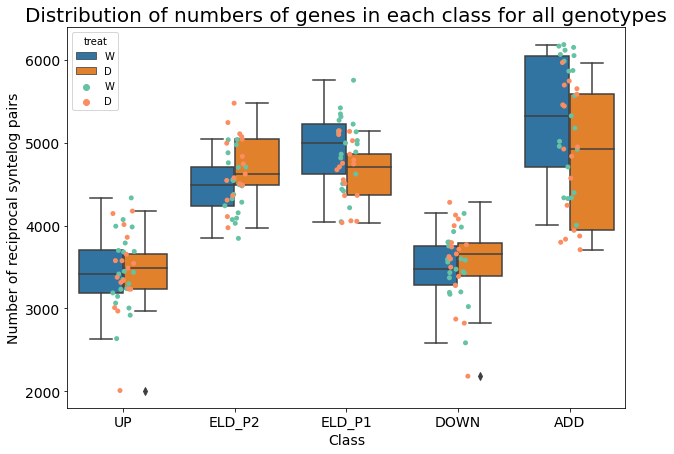

In [14]:
fig,ax = plt.subplots(figsize=(10,7))

sns.boxplot(data=classcounts,x="Class",y="Gene",hue="treat")
sns.stripplot(data=classcounts,x="Class",y="Gene",hue="treat",palette="Set2")
ax.set_title("Distribution of numbers of genes in each class for all genotypes",fontsize=20)
ax.tick_params(which="both",labelsize=14)
ax.set_ylabel("Number of reciprocal syntelog pairs",fontsize=14)
ax.set_xlabel("Class",fontsize=14)

plt.savefig("./top30pct_figures/top30_singlebox_allgt_ngenes_byclass.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_singlebox_allgt_ngenes_byclass.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_singlebox_allgt_ngenes_byclass.svg",dpi=200,bbox_inches="tight")

In [15]:
classcounts[classcounts["Class"]=="UP"].sort_values(by="Gene")

,phys,genotype,treat,Class,Gene
4,C3,13,D,UP,2008
39,C3,45,W,UP,2635
99,facultative_CAM,15,W,UP,2918
54,C3,56,D,UP,2968
184,possible_fac_CAM,52,W,UP,3004
34,C3,45,D,UP,3009
134,possible_fac_CAM,1AB,W,UP,3064
144,possible_fac_CAM,2AB,W,UP,3145
84,C3,Eudy,W,UP,3187
164,possible_fac_CAM,46,W,UP,3231


In [16]:
classcounts.head()

,phys,genotype,treat,Class,Gene
9,C3,13,W,UP,3299
19,C3,18,W,UP,3436
29,C3,36,W,UP,3415
39,C3,45,W,UP,2635
49,C3,55,W,UP,3700


In [17]:
# find mean numbers of genes in each class overall & for each physiological set
cmeans = classcounts.groupby(["treat","Class"]).mean().reset_index()
cmeans["phys"] = "all"
cmeans.head()

,treat,Class,Gene,phys
0,D,ADD,4838.352941,all
1,D,DOWN,3554.352941,all
2,D,ELD_P1,4640.352941,all
3,D,ELD_P2,4707.411765,all
4,D,UP,3441.764706,all


In [18]:
cmeans2 = classcounts.groupby(["phys","treat","Class"]).mean().reset_index()
cmeans2.head()

,phys,treat,Class,Gene
0,C3,D,ADD,4588.333333
1,C3,D,DOWN,3271.888889
2,C3,D,ELD_P1,4707.000000
3,C3,D,ELD_P2,4881.555556
4,C3,D,UP,3232.666667


In [19]:
cmeans = pd.concat([cmeans[["phys","treat","Class","Gene"]],cmeans2])

In [20]:
cmeans = cmeans.round()
cmeans["Gene"] = cmeans["Gene"].astype(int)
cmeans.head()

,phys,treat,Class,Gene
0,all,D,ADD,4838
1,all,D,DOWN,3554
2,all,D,ELD_P1,4640
3,all,D,ELD_P2,4707
4,all,D,UP,3442


In [21]:
cmeans.rename(columns={"phys":"Gene Set","Gene":"Mean Number of Syntelogs","treat":"Treatment"},inplace=True)

In [22]:
cmeans.to_csv("./mean_genenumbers_hybexpclass_acrossgt.csv",sep=",",header=True,index=False)

## Find CAM genes in the results & plot summaries

In [23]:
## load CAM annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [24]:
# load synteny information
syn = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",header="infer")
syn.head()

,GeneID,syntelogID
0,YufilH1000002m.g,recip_syn1
1,Yucal.01G000100.v2.1,recip_syn1
2,YufilH1000007m.g,recip_syn2
3,Yucal.01G000200.v2.1,recip_syn2
4,YufilH1000011m.g,recip_syn3


In [25]:
# merge with CAM annotation
camsyn = cam.merge(syn)
camsyn.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya,recip_syn3628
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya,recip_syn7619
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya,recip_syn13926
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya,recip_syn6335


In [26]:
# merge with res
camres = camsyn.merge(res.rename(columns={"Gene":"syntelogID"}))
camres.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.012556,1.361738,18_D,18,D,C3
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.452933,0.797308,2AB_D,2AB,D,possible_fac_CAM
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.998544,1.344955,1AB_D,1AB,D,possible_fac_CAM
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,6,UP,0.755518,1.112692,19_D,19,D,facultative_CAM
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.329355,1.680807,G_D,G,D,C3


In [27]:
cam_class_sum = camres.groupby(["gene_abbr_unique","Class","treat"]).count().reset_index()[["gene_abbr_unique","Class","treat","genotype"]]
cam_class_sum.head()

,gene_abbr_unique,Class,treat,genotype
0,Ya_BPPC_1,ADD,W,1
1,Ya_BPPC_1,DOWN,D,4
2,Ya_BPPC_1,DOWN,W,11
3,Ya_BPPC_1,ELD_P1,W,2
4,Ya_BPPC_1,ELD_P2,W,6


In [28]:
cam_class_sum = cam_class_sum.sort_values(by=["gene_abbr_unique","treat"],ascending=False)

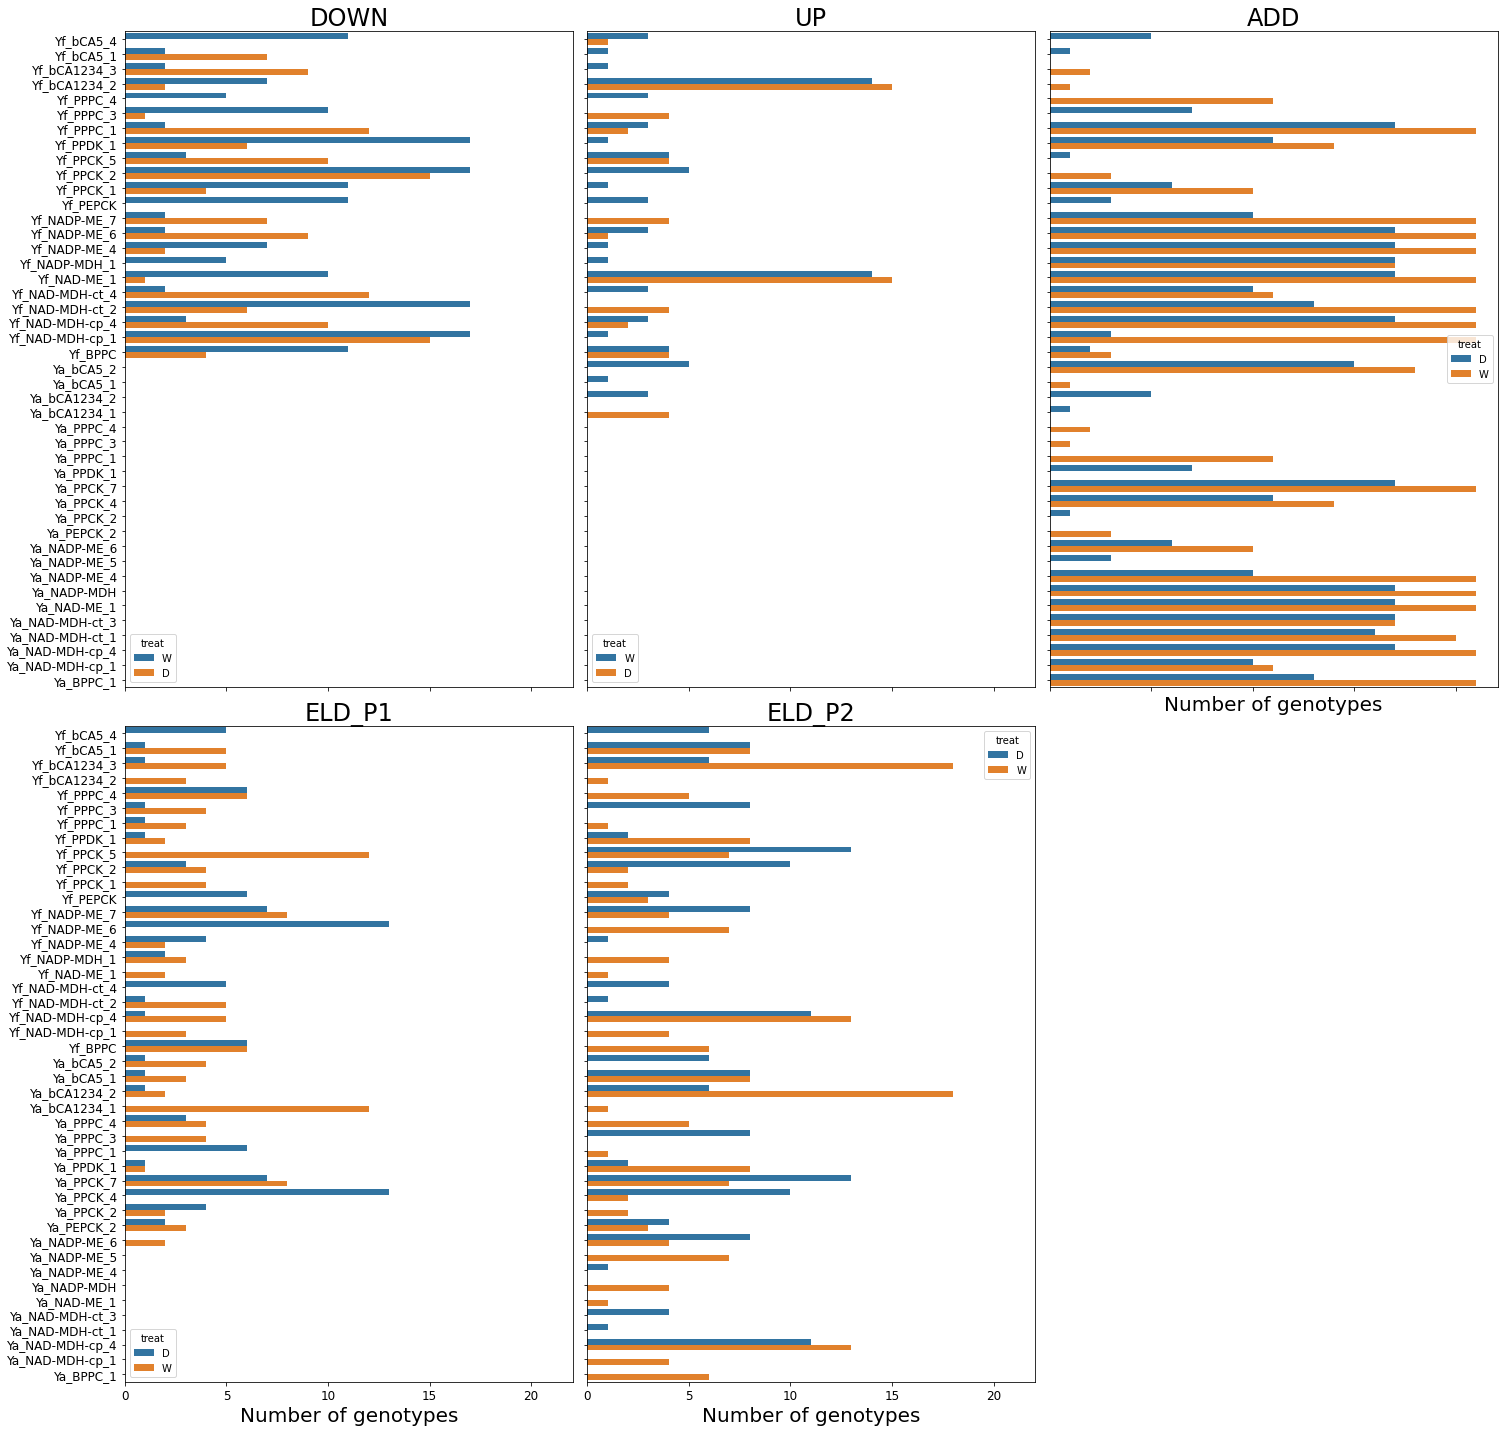

In [29]:
# for each class, plot number of genotype/treatments for each CAM gene
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(21,20),sharex=True,sharey=True)

r=0
c=0
for i in cam_class_sum["Class"].unique():
    df = cam_class_sum[cam_class_sum["Class"]==i]
    sns.barplot(ax=ax[r,c],data=df,x="genotype",y="gene_abbr_unique",hue="treat")
    ax[r,c].set_title(i,fontsize=24)
    ax[r,c].set_ylabel("")
    ax[r,c].set_xticks(np.arange(0,21,5))
    ax[r,c].tick_params(which="both",labelsize=12)
    
    if (r==0 and c<2):
        ax[r,c].set_xlabel("")
    else:
        ax[r,c].set_xlabel("Number of genotypes",fontsize=20)
    
    
    if c<2:
        c+=1
    else:
        c=0
        r=1
        
fig.tight_layout()
fig.delaxes(ax[1,2])

plt.savefig("./top30pct_figures/top30_camgenes_exp_partitioning_summary.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_camgenes_exp_partitioning_summary.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_camgenes_exp_partitioning_summary.svg",dpi=200,bbox_inches="tight")

In [30]:
camcounts = camres.groupby(["phys","genotype","treat","Class"]).count().reset_index()[["phys","genotype","treat","Class","syntelogID"]]
camcounts.head()

,phys,genotype,treat,Class,syntelogID
0,C3,13,D,ADD,25
1,C3,13,D,DOWN,8
2,C3,13,D,ELD_P1,2
3,C3,13,D,ELD_P2,10
4,C3,13,W,ADD,29


In [31]:
order = camcounts.sort_values(by=["treat","phys"],ascending=False)["genotype"].unique()

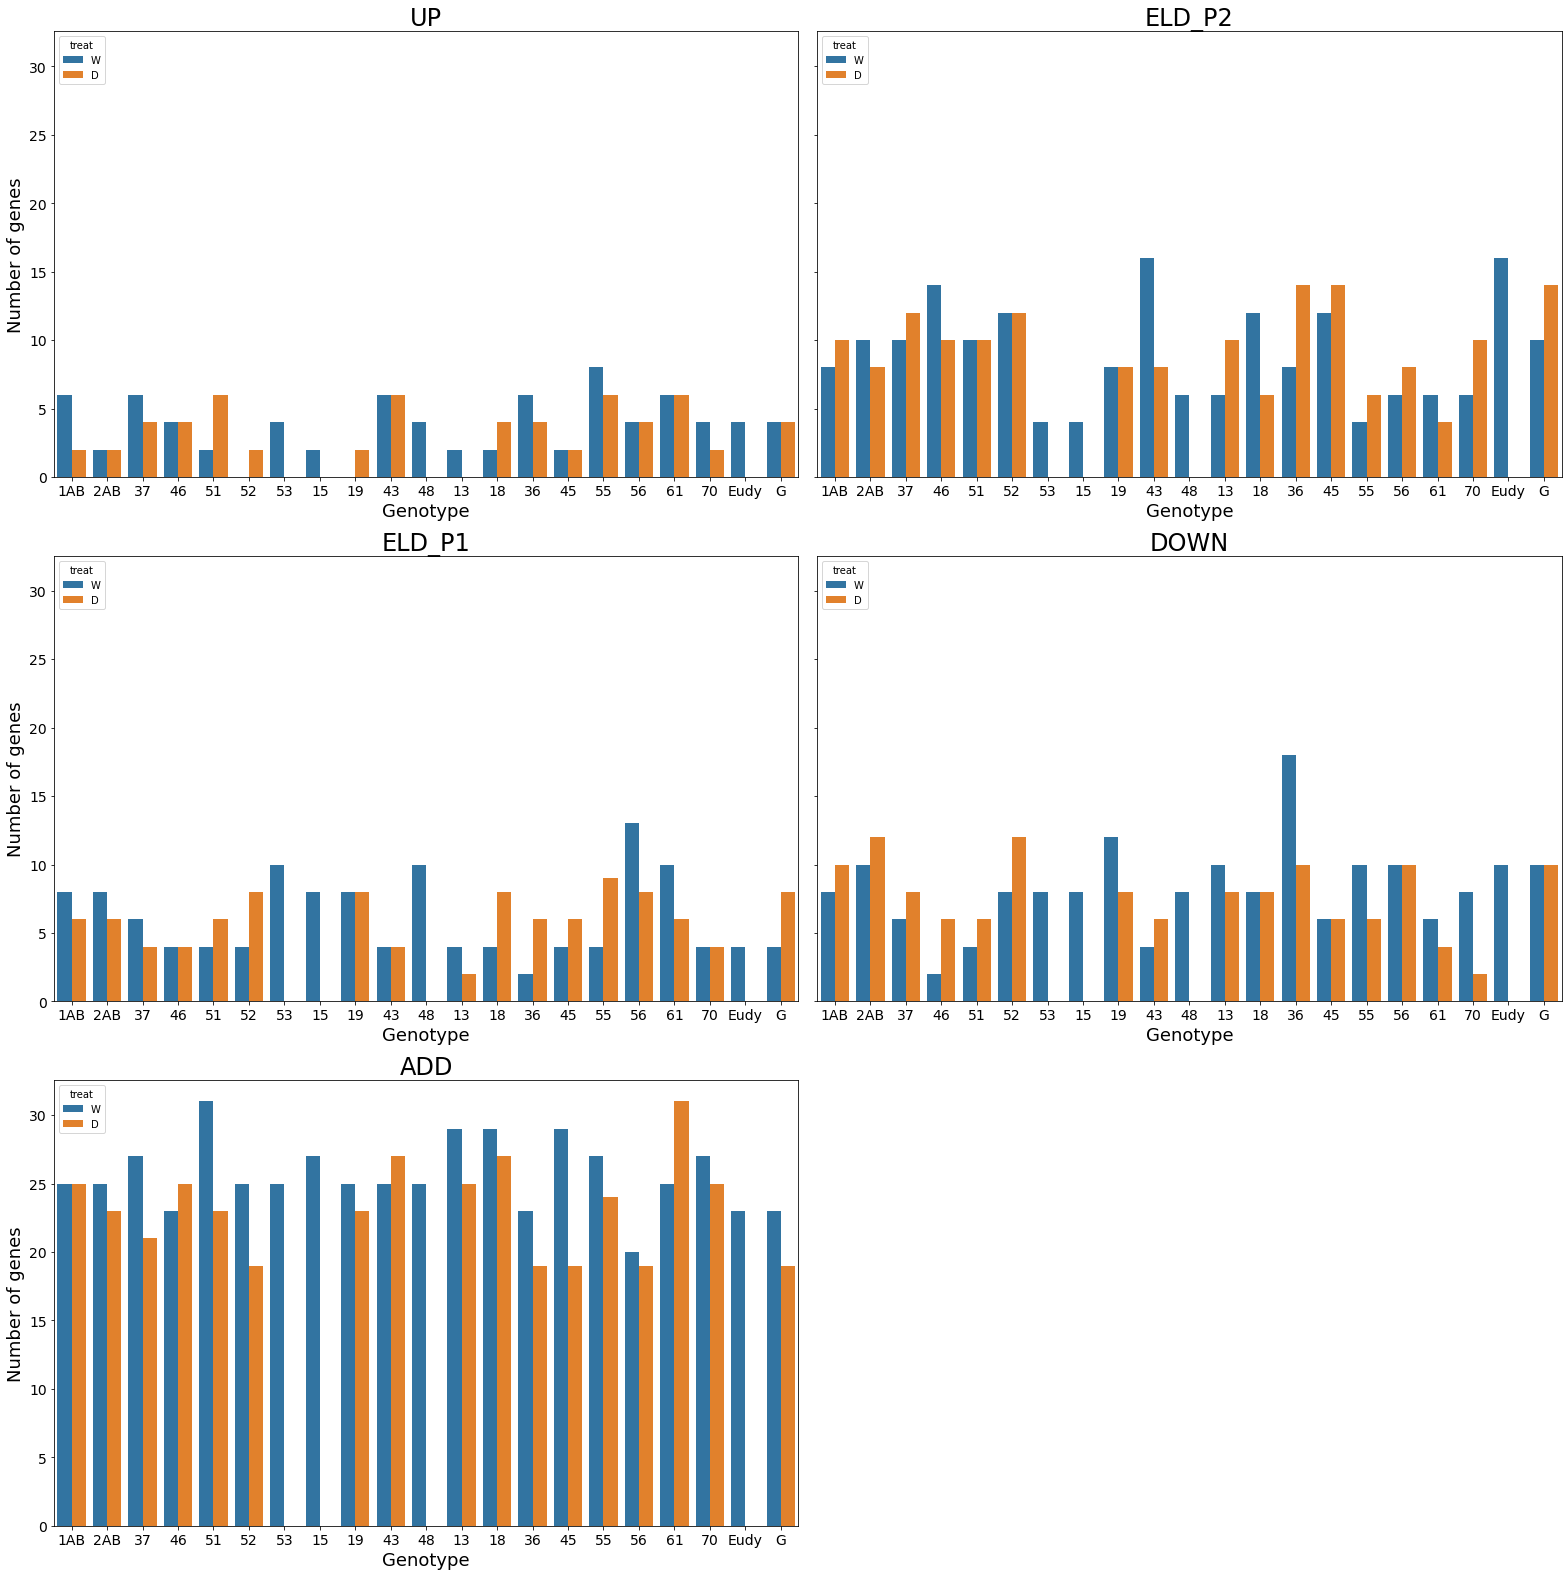

In [32]:
fig,ax = plt.subplots(nrows=3,ncols=2,figsize=(22,22),sharey=True)
r=0
c=0
for i in camcounts.sort_values(by="Class",ascending=False)["Class"].unique():
    df = subcounts(camcounts,"Class",i)
    gtx = len(df["genotype"].unique())
    sns.barplot(ax=ax[r,c],data=df,x="genotype",y="syntelogID",hue="treat",order=order)
    ax[r,c].set_title(i,fontsize=24)
    ax[r,c].tick_params(which="both",labelsize=14)
    ax[r,c].set_xlabel("Genotype",fontsize=18)
    if c==0:
        ax[r,c].set_ylabel("Number of genes",fontsize=18)
    else:
        ax[r,c].set_ylabel("")
    
    if c<1:
        c+=1
    else:
        c=0
        r+=1
        
fig.tight_layout()
fig.delaxes(ax[2,1])

plt.savefig("./top30pct_figures/top30_ncamgenes_gttreat_class.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_ncamgenes_gttreat_class.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_ncamgenes_gttreat_class.svg",dpi=200,bbox_inches="tight")

## Mar. 19, 2026: Re-make CAM gene figure (# of genotypes for each gene in a class) with physiology breakout

In [37]:
camres.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.012556,1.361738,18_D,18,D,C3
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.452933,0.797308,2AB_D,2AB,D,possible_fac_CAM
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.998544,1.344955,1AB_D,1AB,D,possible_fac_CAM
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,6,UP,0.755518,1.112692,19_D,19,D,facultative_CAM
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.329355,1.680807,G_D,G,D,C3


In [78]:
cam_class_sum = camres.groupby(["gene_abbr_unique","Class","phys","treat"]).count().reset_index()[["gene_abbr_unique",
                                                                                                   "Class","treat",
                                                                                                   "phys","genotype"]]
cam_class_sum.head()

,gene_abbr_unique,Class,treat,phys,genotype
0,Ya_BPPC_1,ADD,W,C3,1
1,Ya_BPPC_1,DOWN,D,C3,4
2,Ya_BPPC_1,DOWN,W,C3,8
3,Ya_BPPC_1,DOWN,W,facultative_CAM,2
4,Ya_BPPC_1,DOWN,W,possible_fac_CAM,1


In [79]:
# add subgenome column
cam_class_sum["subgenome"] = cam_class_sum["gene_abbr_unique"].str.split("_").str[0]
cam_class_sum.head()

,gene_abbr_unique,Class,treat,phys,genotype,subgenome
0,Ya_BPPC_1,ADD,W,C3,1,Ya
1,Ya_BPPC_1,DOWN,D,C3,4,Ya
2,Ya_BPPC_1,DOWN,W,C3,8,Ya
3,Ya_BPPC_1,DOWN,W,facultative_CAM,2,Ya
4,Ya_BPPC_1,DOWN,W,possible_fac_CAM,1,Ya


In [80]:
cam_class_sum["phystreat"] = cam_class_sum["phys"]+"_"+cam_class_sum["treat"]

In [81]:
cam_class_sum["phystreat"].unique()

array(['C3_W', 'C3_D', 'facultative_CAM_W', 'possible_fac_CAM_W',
       'facultative_CAM_D', 'possible_fac_CAM_D'], dtype=object)

In [47]:
# convert to wide - write a function for this
def to_wide_data(sg,c,data=cam_class_sum):
    sub = data[(data["subgenome"]==sg)&(data["Class"]==c)]
    wide = pd.pivot(sub,index=["gene_abbr_unique"],columns="phystreat",values="genotype")
    wide.fillna(0,inplace=True)
    return wide

In [42]:
custompal = {
    "C3_W":"skyblue",
    "facultative_CAM_W":"navy",
    "possible_fac_CAM_W":"royalblue",
    "C3_D":"coral",
    "facultative_CAM_D":"saddlebrown",
    "possible_fac_CAM_D":"orangered"
}

In [57]:
# make a plotting function
def plot_class(c,data=cam_class_sum,palette=custompal):
    # get wide data for each subgenome
    yawide = to_wide_data("Ya",c,data)
    yfwide = to_wide_data("Yf",c,data)
    
    # make colormap object
    cmap = LinearSegmentedColormap.from_list("custom",list(palette.values()))
    
    # set up the figure
    sns.set_theme(style="whitegrid")
    fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharex=True)
    
    # plot the data
    yawide.plot(kind="barh",ax=ax[0],stacked=True,colormap=cmap)
    ax[0].set_title("Y. aloifolia (CAM parent)",fontsize=20)
    ax[0].tick_params(which="both",labelsize=14)
    ax[0].set_ylabel("")
    ax[0].set_xlabel("Number of genotypes",fontsize=14)
    ax[0].set_xticks(ticks=range(0,41,5))
    
    # plot Y. filamentosa-origin data
    yfwide.plot(kind="barh",ax=ax[1],stacked=True,colormap=cmap)
    ax[1].set_title("Y. filamentosa (C3 parent)",fontsize=20)
    ax[1].tick_params(which="both",labelsize=14)
    ax[1].set_ylabel("")
    ax[1].set_xlabel("Number of genotypes",fontsize=14)
    ax[1].set_xticks(ticks=range(0,41,5))
    
    fig.tight_layout()

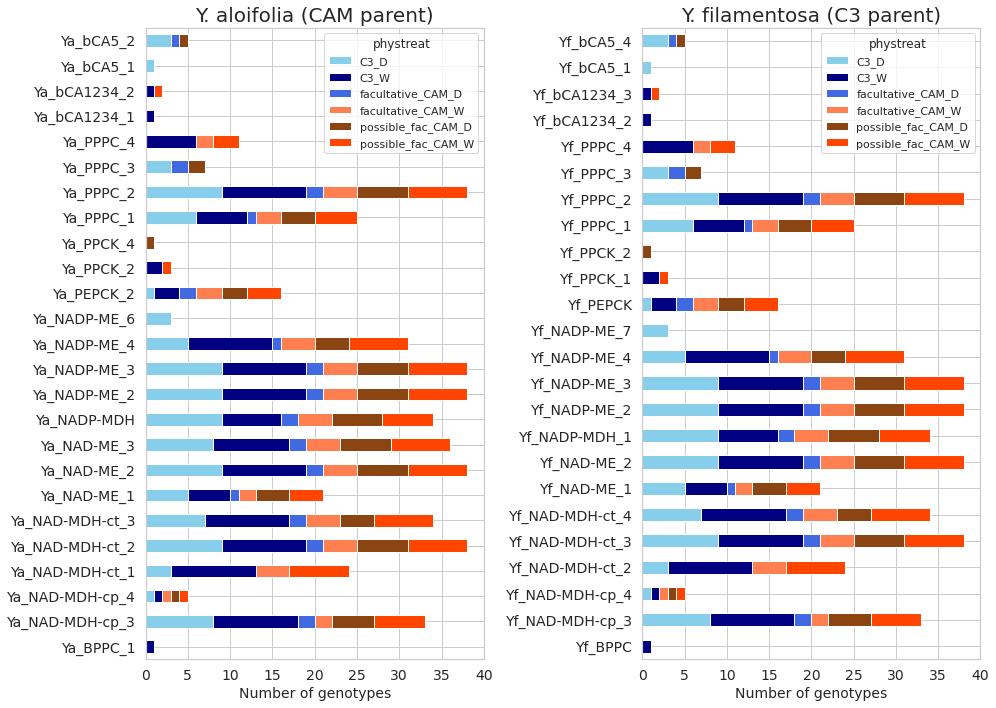

In [58]:
plot_class("ADD")

In [60]:
camsyn.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya,recip_syn3628
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya,recip_syn7619
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya,recip_syn13926
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya,recip_syn6335


In [63]:
# actually: because of the use of reciprocal syntelogs, plotting by both subgenomes is not necessary, as the data will be identical.

# just plot all 5 classes for a single subgenome set - but first: make a dict renaming the Ya gene names to the 
## correct reciprocal syntelog pairings
synpairs = {}
for i in camsyn["syntelogID"].unique():
    df = camsyn[camsyn["syntelogID"]==i]
    for j in df["gene_abbr_unique"]:
        if j.startswith("Ya"):
            jya = j
        else:
            jyf = j
    synpairs[jya] = jya+"/"+jyf
synpairs

{'Ya_bCA1234_1': 'Ya_bCA1234_1/Yf_bCA1234_2',
 'Ya_bCA1234_2': 'Ya_bCA1234_2/Yf_bCA1234_3',
 'Ya_bCA5_1': 'Ya_bCA5_1/Yf_bCA5_1',
 'Ya_bCA5_2': 'Ya_bCA5_2/Yf_bCA5_4',
 'Ya_NAD-MDH-cp_1': 'Ya_NAD-MDH-cp_1/Yf_NAD-MDH-cp_1',
 'Ya_NAD-MDH-cp_2': 'Ya_NAD-MDH-cp_2/Yf_NAD-MDH-cp_2',
 'Ya_NAD-MDH-cp_3': 'Ya_NAD-MDH-cp_3/Yf_NAD-MDH-cp_3',
 'Ya_NAD-MDH-cp_4': 'Ya_NAD-MDH-cp_4/Yf_NAD-MDH-cp_4',
 'Ya_NAD-MDH-ct_1': 'Ya_NAD-MDH-ct_1/Yf_NAD-MDH-ct_2',
 'Ya_NAD-MDH-ct_2': 'Ya_NAD-MDH-ct_2/Yf_NAD-MDH-ct_3',
 'Ya_NAD-MDH-ct_3': 'Ya_NAD-MDH-ct_3/Yf_NAD-MDH-ct_4',
 'Ya_NADP-MDH': 'Ya_NADP-MDH/Yf_NADP-MDH_1',
 'Ya_BPPC_1': 'Ya_BPPC_1/Yf_BPPC',
 'Ya_PPPC_1': 'Ya_PPPC_1/Yf_PPPC_1',
 'Ya_PPPC_2': 'Ya_PPPC_2/Yf_PPPC_2',
 'Ya_PPPC_3': 'Ya_PPPC_3/Yf_PPPC_3',
 'Ya_PPPC_4': 'Ya_PPPC_4/Yf_PPPC_4',
 'Ya_PPCK_2': 'Ya_PPCK_2/Yf_PPCK_1',
 'Ya_PPCK_4': 'Ya_PPCK_4/Yf_PPCK_2',
 'Ya_PPCK_6': 'Ya_PPCK_6/Yf_PPCK_4',
 'Ya_PPCK_7': 'Ya_PPCK_7/Yf_PPCK_5',
 'Ya_NAD-ME_1': 'Ya_NAD-ME_1/Yf_NAD-ME_1',
 'Ya_NAD-ME_2': 'Ya_NAD-ME_2/Y

In [64]:
# as this is a much better syntelog naming system than what I have used before, save it for later use
with open("/home/leviathan22/yucca-genomics/rename_camsyn_ya_to_synpairs.json","w+") as outfile:
    json.dump(synpairs,outfile)

In [82]:
ccs2 = cam_class_sum[cam_class_sum["subgenome"]=="Ya"]
ccs2["gene_abbr_unique"] = ccs2["gene_abbr_unique"].map(synpairs)
ccs2.head()

/tmp/ipykernel_17241/523216646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ccs2["gene_abbr_unique"] = ccs2["gene_abbr_unique"].map(synpairs)


,gene_abbr_unique,Class,treat,phys,genotype,subgenome,phystreat
0,Ya_BPPC_1/Yf_BPPC,ADD,W,C3,1,Ya,C3_W
1,Ya_BPPC_1/Yf_BPPC,DOWN,D,C3,4,Ya,C3_D
2,Ya_BPPC_1/Yf_BPPC,DOWN,W,C3,8,Ya,C3_W
3,Ya_BPPC_1/Yf_BPPC,DOWN,W,facultative_CAM,2,Ya,facultative_CAM_W
4,Ya_BPPC_1/Yf_BPPC,DOWN,W,possible_fac_CAM,1,Ya,possible_fac_CAM_W


In [83]:
ccs2.drop("subgenome",axis=1,inplace=True)
ccs2.drop_duplicates(inplace=True)

/tmp/ipykernel_17241/3229256373.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ccs2.drop("subgenome",axis=1,inplace=True)
/tmp/ipykernel_17241/3229256373.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ccs2.drop_duplicates(inplace=True)


In [84]:
len(ccs2.index)

308

In [91]:
# fix this function
def to_wide_data(c,data=ccs2):
    sub = data[data["Class"]==c]
    wide = pd.pivot(sub,index=["gene_abbr_unique"],columns="phystreat",values="genotype")
    wide.fillna(0,inplace=True)
    return wide

In [74]:
cmap = LinearSegmentedColormap.from_list("custom",list(custompal.values()))

In [92]:
add = to_wide_data("ADD")
eld1 = to_wide_data("ELD_P1")
eld2 = to_wide_data("ELD_P2")
up = to_wide_data("UP")
down = to_wide_data("DOWN")

In [128]:
# add missing data for plotting to the last 4 dataframes in the list above
def fill_missing(df,base=add):
    df = df.reset_index()
    base = base.reset_index()
    
    adddict = {}
    for i in df.columns:
        adddict[i] = []
    
    for i in base["gene_abbr_unique"]:
        if i not in list(df["gene_abbr_unique"]):
            adddict["gene_abbr_unique"].append(i)
            for k,v in adddict.items():
                if k!="gene_abbr_unique":
                    v.append(0)
                    
    dfadd = pd.DataFrame(adddict)
    dfmerge = pd.concat([df,dfadd])
    
    return dfmerge.set_index("gene_abbr_unique")

In [130]:
eld1 = fill_missing(eld1)
eld2 = fill_missing(eld2)
up = fill_missing(up)
down = fill_missing(down)

In [135]:
custompal

{'C3_W': 'skyblue',
 'facultative_CAM_W': 'navy',
 'possible_fac_CAM_W': 'royalblue',
 'C3_D': 'coral',
 'facultative_CAM_D': 'saddlebrown',
 'possible_fac_CAM_D': 'orangered'}

In [163]:
def plot_subplot(data,c,axc,axs=ax):
    # reorder columns of data according to custompal order
    data = data[list(custompal.keys())]
    
    data.plot(kind="barh",ax=axs[axc],stacked=True,colormap=cmap)
    axs[axc].set_title(c,fontsize=28)
    axs[axc].tick_params(which="both",labelsize=20)
    axs[axc].set_ylabel("")
    axs[axc].set_xticks(ticks=range(0,41,5))
    axs[axc].legend(labels=["C3 W","possibly facultative CAM W","facultative CAM W",
                       "C3 D","possibly facultative CAM D","facultative CAM D"],fontsize=16)

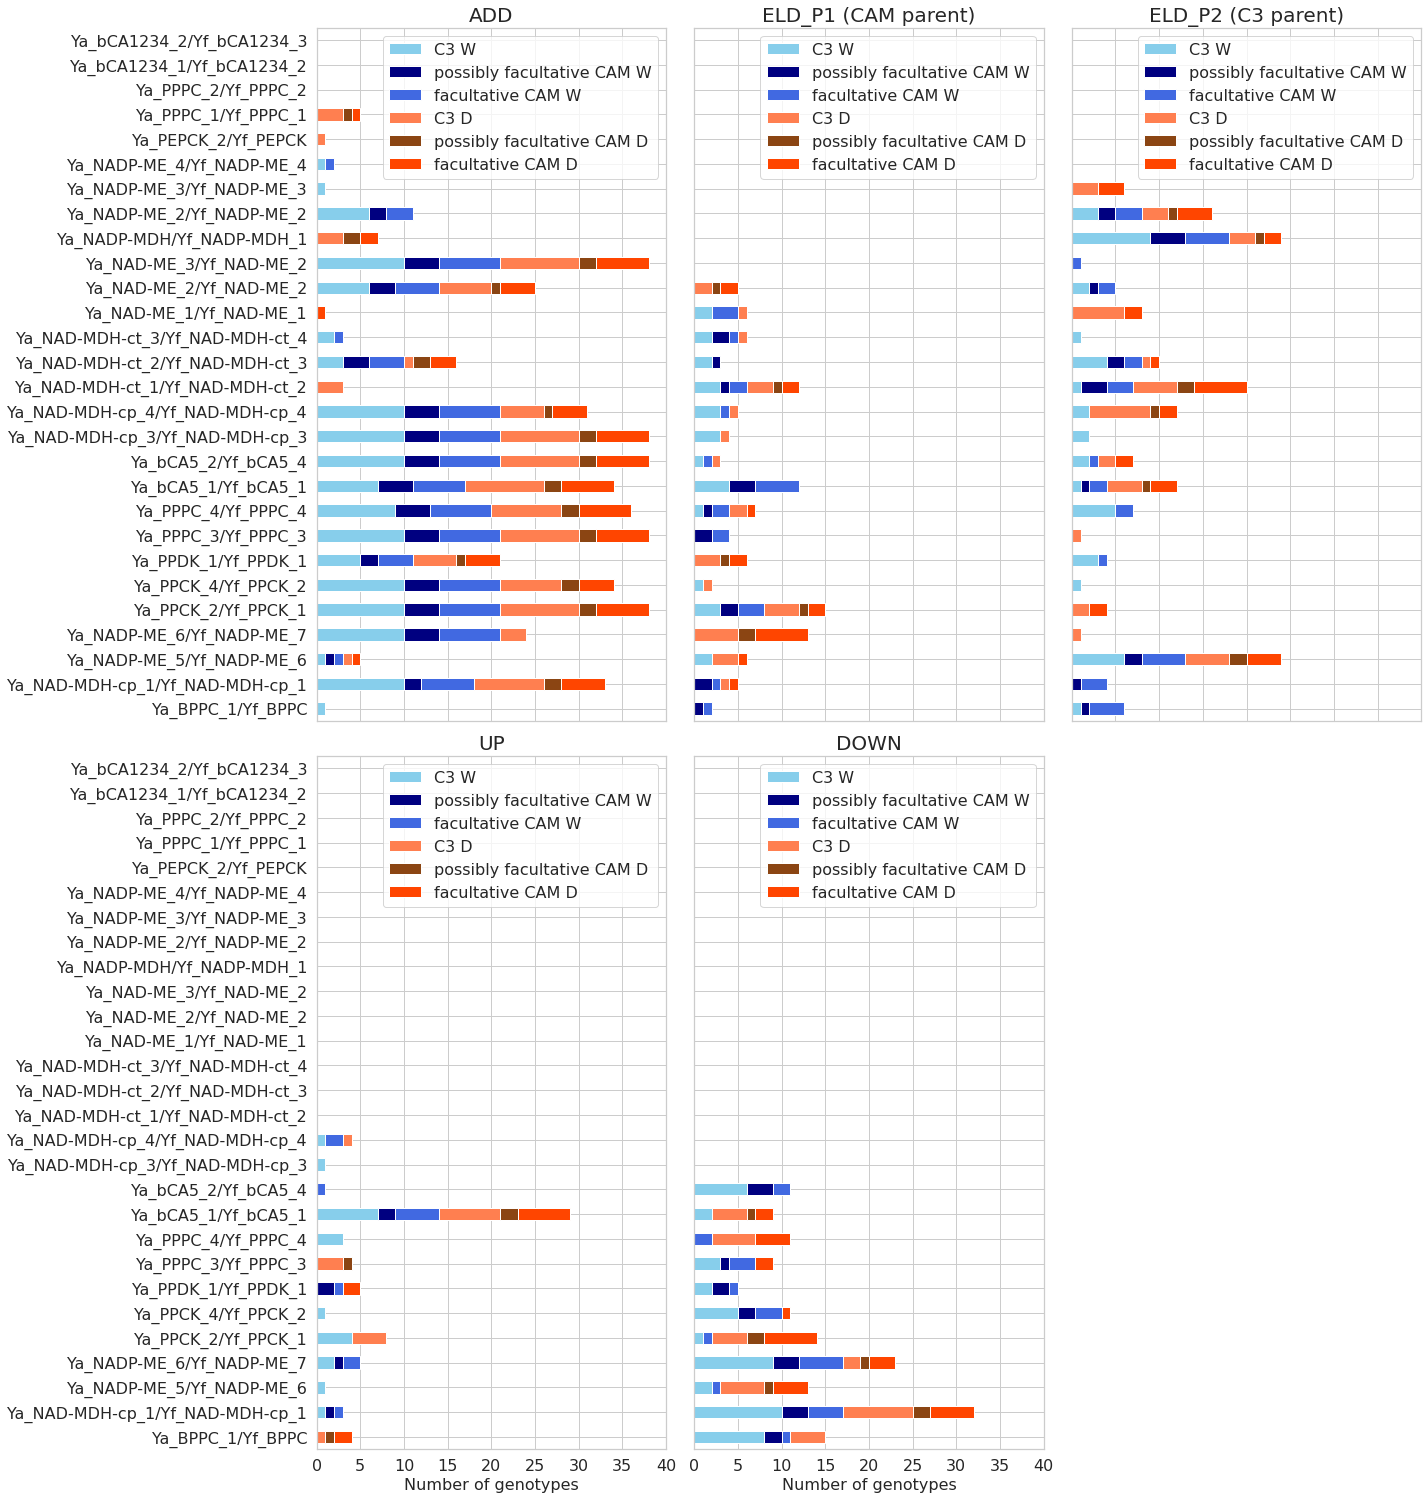

In [150]:
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,21),sharex=True,sharey=True)

plot_subplot(add,"ADD",(0,0),ax)
plot_subplot(eld1,"ELD_P1 (CAM parent)",(0,1),ax)
plot_subplot(eld2,"ELD_P2 (C3 parent)",(0,2),ax)
plot_subplot(up,"UP",(1,0),ax)
plot_subplot(down,"DOWN",(1,1),ax)

ax[1,0].set_xlabel("Number of genotypes",fontsize=16)
ax[1,1].set_xlabel("Number of genotypes",fontsize=16)
#ax[1,2].set_xlabel("Number of genotypes",fontsize=14)
#ax[0,1].get_legend().remove()
#ax[0,2].get_legend().remove()
#ax[1,0].get_legend().remove()
#ax[1,2].get_legend().remove()

#plt.suptitle("CAM genes in expression partitioning (DE relative to parents)",fontsize=24)

fig.delaxes(ax[1,2])
fig.tight_layout()

plt.savefig("./hybexp_campartitions_byphys_top30_forposter.png",dpi=200,bbox_inches="tight")
plt.savefig("./hybexp_campartitions_byphys_top30_forposter.svg",dpi=200,bbox_inches="tight")
plt.savefig("./hybexp_campartitions_byphys_top30_forposter.pdf",dpi=200,bbox_inches="tight")

In [152]:
# repeat for just the three families of interest: PPPC, PPCK, and BPPC
def subdata(df):
    sublist = []
    for i in df.index:
        if "BPPC" in i:
            sublist.append(i)
        elif "PPPC" in i:
            sublist.append(i)
        elif "PPCK" in i:
            sublist.append(i)
    
    subdf = df[df.index.isin(sublist)]
    return subdf

In [154]:
addsub = subdata(add)
eld1sub = subdata(eld1)
eld2sub = subdata(eld2)
upsub = subdata(up)
downsub = subdata(down)

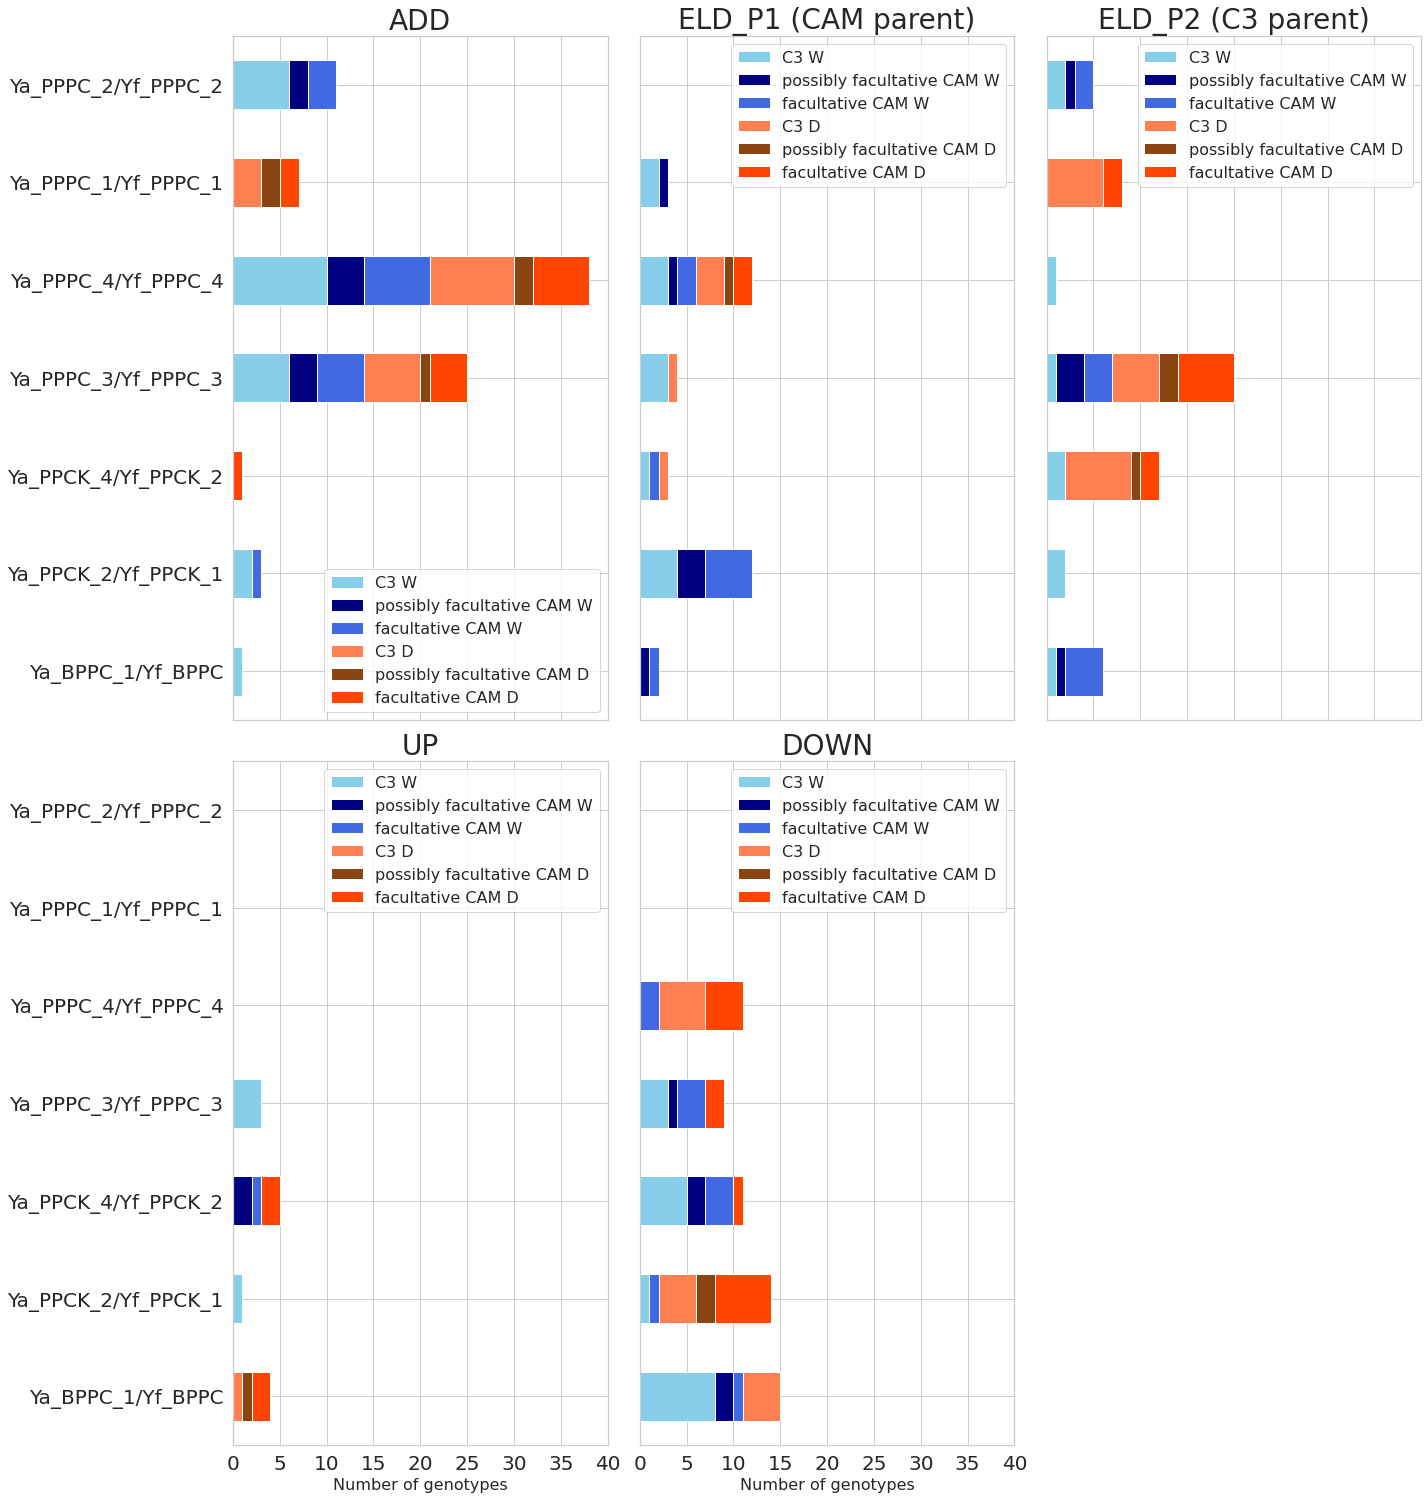

In [165]:
# re-plot
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,21),sharex=True,sharey=True)

plot_subplot(addsub,"ADD",(0,0),ax)
plot_subplot(eld1sub,"ELD_P1 (CAM parent)",(0,1),ax)
plot_subplot(eld2sub,"ELD_P2 (C3 parent)",(0,2),ax)
plot_subplot(upsub,"UP",(1,0),ax)
plot_subplot(downsub,"DOWN",(1,1),ax)

ax[1,0].set_xlabel("Number of genotypes",fontsize=16)
ax[1,1].set_xlabel("Number of genotypes",fontsize=16)
#ax[1,2].set_xlabel("Number of genotypes",fontsize=14)
#ax[0,1].get_legend().remove()
#ax[0,2].get_legend().remove()
#ax[1,0].get_legend().remove()
#ax[1,2].get_legend().remove()
ax[0,0].legend(loc="lower right", labels=["C3 W","possibly facultative CAM W","facultative CAM W",
                       "C3 D","possibly facultative CAM D","facultative CAM D"],fontsize=16)

#plt.suptitle("CAM genes in expression partitioning (DE relative to parents)",fontsize=24)

fig.delaxes(ax[1,2])
fig.tight_layout()

plt.savefig("./hybexp_subcampartitions_byphys_top30_forposter.png",dpi=200,bbox_inches="tight")
plt.savefig("./hybexp_subcampartitions_byphys_top30_forposter.svg",dpi=200,bbox_inches="tight")
plt.savefig("./hybexp_subcampartitions_byphys_top30_forposter.pdf",dpi=200,bbox_inches="tight")

In [118]:
# how many CAM genes in each class in at least one genotype?
len(add.index)

25

In [119]:
len(eld1.index)

18

In [120]:
len(eld2.index)

22

In [121]:
len(up.index)

13

In [122]:
len(down.index)

11